Loading the Libraries and datasets

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [9]:
print(f"your rows are {df.shape[0]} and your column are {df.shape[1]}")

your rows are 74 and your column are 20


Now lets see how many column have null values in total

In [11]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Que.1 - Which team Won the Most Matches

Text(0.5, 1.0, 'Most match win by a team')

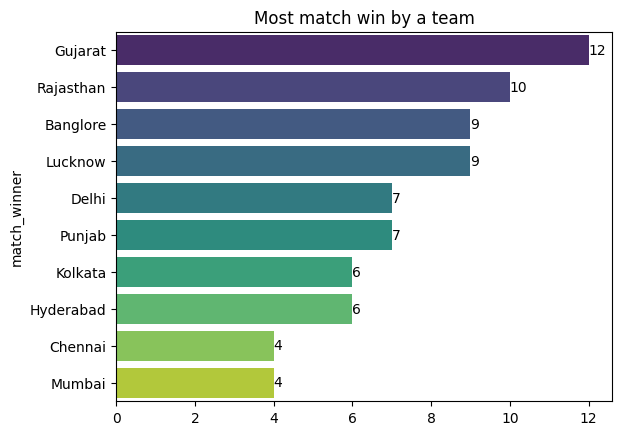

In [23]:
match_wins = df['match_winner'].value_counts()
ax = sns.barplot(y= match_wins.index, x = match_wins.values, palette='viridis')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Most match win by a team")

Que.2- TOSS Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

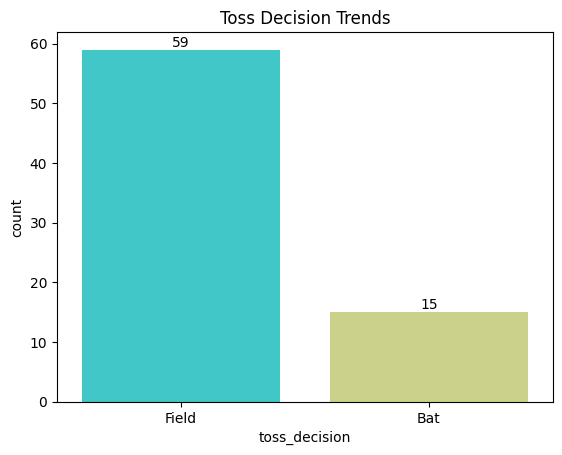

In [28]:
cm = sns.countplot(x=df['toss_decision'],palette='rainbow')
for container in cm.containers:
    cm.bar_label(container)
plt.title("Toss Decision Trends")

Que.3- Toss Winner VS Match Winnner

In [32]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

48.65

Que.4 - How do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Match Winner (Runs vs Wicket)')

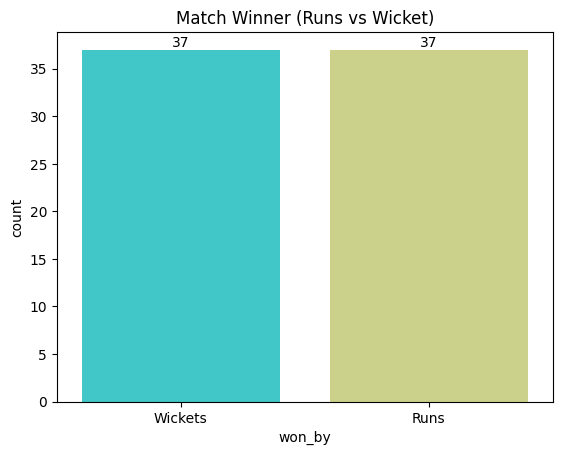

In [36]:
won = sns.countplot(x= df['won_by'],palette='rainbow')
for container in won.containers:
    won.bar_label(container)
plt.title('Match Winner (Runs vs Wicket)')

Key PLayer Performances

1 - Most "Player of the Match" Award

Text(0.5, 1.0, 'Player of the Match')

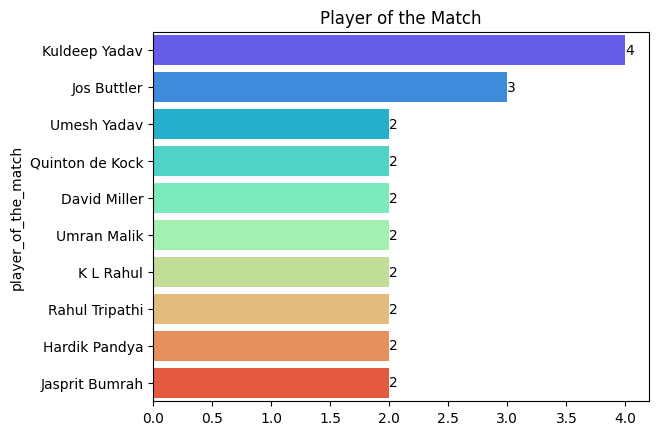

In [92]:
count = df['player_of_the_match'].value_counts().head(10)
count
bar = sns.barplot(x= count.values, y=count.index, palette='rainbow')
for container in bar.containers:
    bar.bar_label(container)
plt.title('Player of the Match')

2- Two Top Scorers

In [45]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

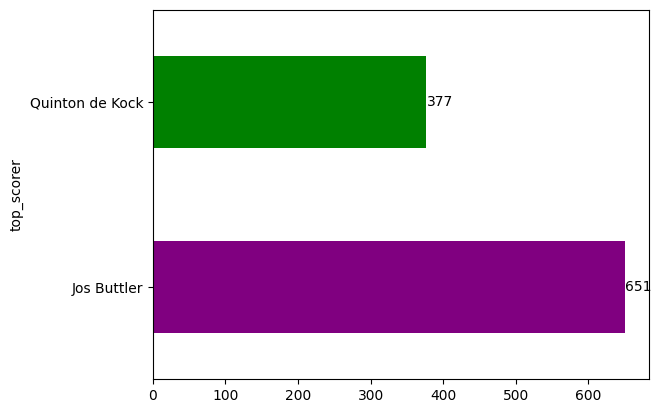

In [51]:
ax = high.plot(kind = 'barh', color=['purple','green'])
for container in ax.containers: 
    ax.bar_label(container)

3- 10 best bolwers

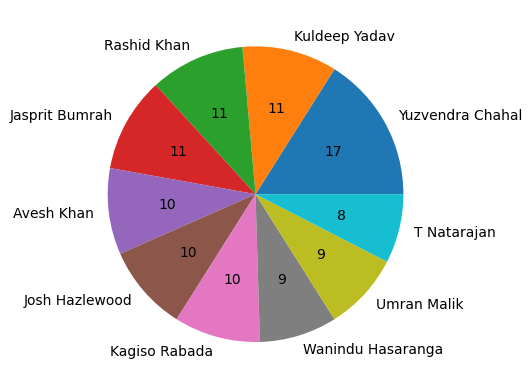

In [94]:
df['highest_wicket'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wicket'] = df['highest_wicket'].astype(int)
bowlers = df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending=False).head(10)
bowlers
total = sum(bowlers.values)
plt.pie(
    bowlers.values,
    labels=bowlers.index,
    autopct=lambda pct: round(pct * total / 100)
)
plt.show()

Venue Analysis

Most Match Player in Venue

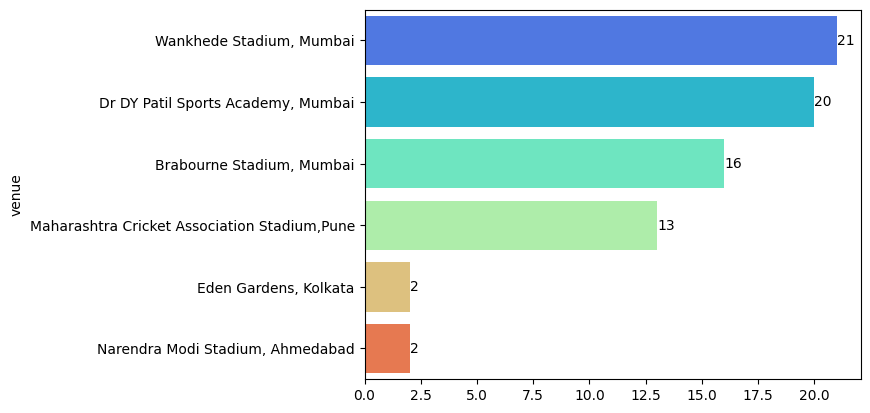

In [97]:
vanue_count = df['venue'].value_counts()
vanue_count
mx = sns.barplot(y= vanue_count.index, x= vanue_count.values, palette='rainbow')
for container in mx.containers: 
    mx.bar_label(container)

Custom Question and Insights

Q1: Who won the highest margin by run?

In [86]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Q2: which player had the higest score individual?

In [88]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figure?

In [91]:
df[df['highest_wicket'] == df['highest_wicket'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
